In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [3]:
data=pd.read_csv("Mall_Customers.csv")
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
data.shape

(200, 5)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [7]:
data.isnull().sum()

Q1 = data["Annual Income (k$)"].quantile(0.25)
Q3 = data["Annual Income (k$)"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[(data["Annual Income (k$)"] < lower_bound) | (data["Annual Income (k$)"] > upper_bound)]
print(outliers)


     CustomerID Gender  Age  Annual Income (k$)  Spending Score (1-100)
198         199   Male   32                 137                      18
199         200   Male   30                 137                      83


In [10]:
from sklearn.preprocessing import StandardScaler


X = data.drop(["CustomerID", "Gender"], axis=1)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]  


array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992]])

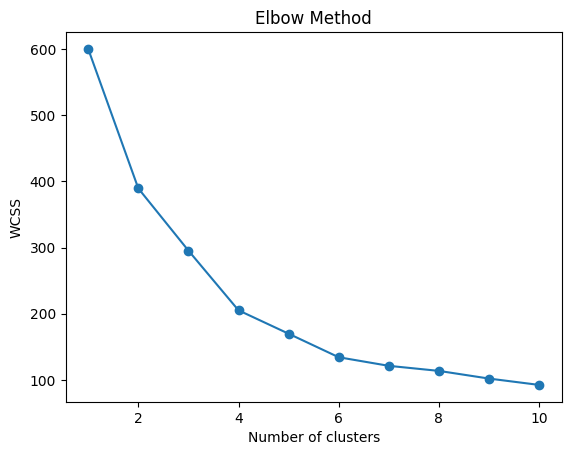

In [11]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()


In [12]:
scores=[]
for k in range(2,11):
    model=KMeans(n_clusters=k,random_state=42)
    labels=model.fit_predict(X_scaled)
    score=silhouette_score(X_scaled,labels)
    scores.append(score)
    print(f"K={k} Dilhouette Score={score:.3f}")





kmeans = KMeans(n_clusters=5, random_state=42)
data["Cluster"] = kmeans.fit_predict(X_scaled)


K=2 Dilhouette Score=0.335
K=3 Dilhouette Score=0.358
K=4 Dilhouette Score=0.404
K=5 Dilhouette Score=0.408
K=6 Dilhouette Score=0.431
K=7 Dilhouette Score=0.410
K=8 Dilhouette Score=0.367
K=9 Dilhouette Score=0.374
K=10 Dilhouette Score=0.362


In [14]:

feature_cols = X.columns   

centers = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers, columns=feature_cols)

centers_df


,Age,Annual Income (k$),Spending Score (1-100)
0,55.275862,47.620690,41.706897
1,32.875000,86.100000,81.525000
2,25.769231,26.115385,74.846154
3,26.733333,54.311111,40.911111
4,44.387097,89.774194,18.483871


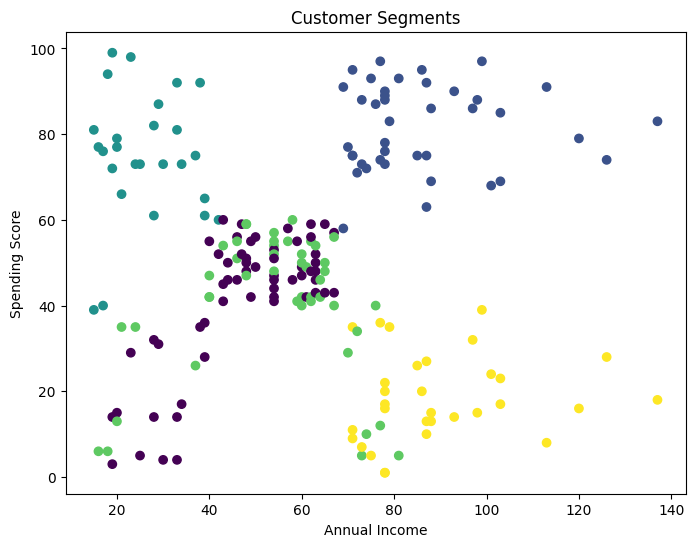

In [15]:
plt.figure(figsize=(8,6))
plt.scatter(data["Annual Income (k$)"],
            data["Spending Score (1-100)"],
            c=data["Cluster"],
            cmap="viridis")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")
plt.show()


In [18]:
new_customer=[[28,40000,10000]]
new_customer_scaled = scaler.transform(new_customer)

In [19]:
prediction=kmeans.predict(new_customer_scaled)
print("Predicted Cluster:", prediction[0])

Predicted Cluster: 1
